## Imports & Setup

In [1]:

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

np.random.seed(42)
plt.style.use("seaborn-v0_8")


## Load Dataset

In [2]:

def load_data(path="train_FD001.txt"):
    cols = (
        ['engine_id','cycle'] +
        ['setting1','setting2','setting3'] +
        [f'sensor{i}' for i in range(1,22)]
    )
    df = pd.read_csv(path, sep=" ", header=None)
    df.dropna(axis=1, inplace=True)
    df.columns = cols
    return df

train_df = load_data()


## RUL Engineering

In [3]:

RUL_CAP = 125

def compute_rul(df, cap=125):
    max_cycles = df.groupby("engine_id")["cycle"].max()
    df["RUL_raw"] = df.apply(lambda r: max_cycles[r.engine_id] - r.cycle, axis=1)
    df["RUL"] = df["RUL_raw"].clip(upper=cap)
    df["RUL_norm"] = df["RUL"] / cap
    return df

train_df = compute_rul(train_df)


## Feature Selection & Scaling

In [4]:

def select_and_scale(df, threshold=0.01):
    sensors = [f"sensor{i}" for i in range(1,22)]
    features = df[sensors].std()[df[sensors].std() > threshold].index.tolist()
    scaler = MinMaxScaler()
    df[features] = scaler.fit_transform(df[features])
    return df, features, scaler

train_df, features, scaler = select_and_scale(train_df)


## Feature Flattening

In [5]:

X_flat, y_flat = [], []

for eid in train_df.engine_id.unique():
    edf = train_df[train_df.engine_id == eid]
    data = edf[features].values
    rul = edf.RUL_norm.values
    for i in range(len(data) - 30):
        X_flat.append(data[i:i+30].flatten())
        y_flat.append(rul[i+30])

X_flat = np.array(X_flat)
y_flat = np.array(y_flat)

X_train, X_val, y_train, y_val = train_test_split(
    X_flat, y_flat, test_size=0.2, random_state=42
)


## Random Forest Training & Evaluation

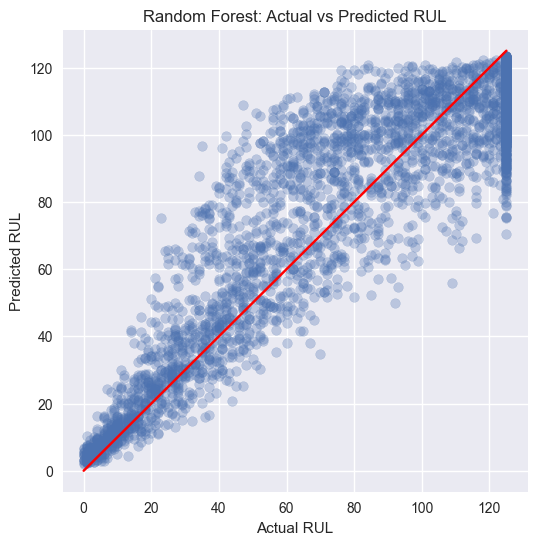

{'RMSE': np.float64(0.14148757280180452),
 'MAE': 0.10897831933031485,
 'R2': 0.821755924722211}

In [6]:

from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

y_pred = model.predict(X_val)

plt.figure(figsize=(6,6))
plt.scatter(y_val*RUL_CAP, y_pred*RUL_CAP, alpha=0.3)
plt.plot([0, RUL_CAP],[0, RUL_CAP],'r')
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Random Forest: Actual vs Predicted RUL")
plt.show()

metrics_rf = {
    "RMSE": np.sqrt(mean_squared_error(y_val, y_pred)),
    "MAE": mean_absolute_error(y_val, y_pred),
    "R2": r2_score(y_val, y_pred)
}
metrics_rf


Actual vs Predicted RUL

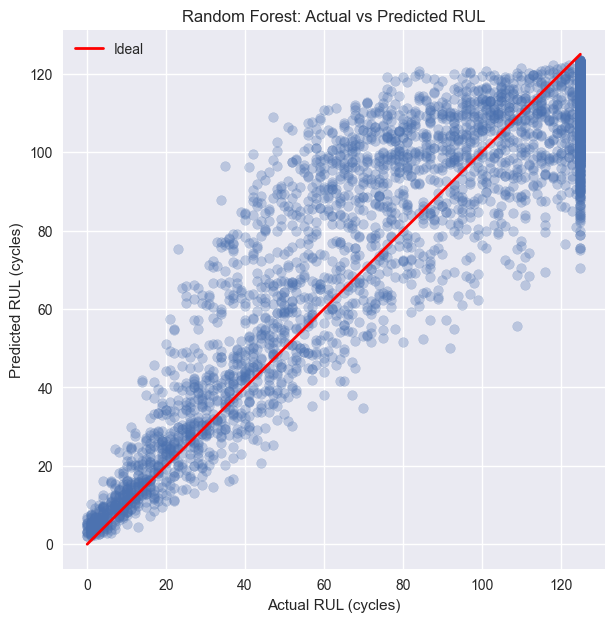

In [7]:
RUL_CAP = 125

y_true_rul = y_val * RUL_CAP
y_pred_rul = y_pred * RUL_CAP

plt.figure(figsize=(7,7))
plt.scatter(y_true_rul, y_pred_rul, alpha=0.3)
plt.plot([0, RUL_CAP], [0, RUL_CAP], 'r', linewidth=2, label="Ideal")
plt.xlabel("Actual RUL (cycles)")
plt.ylabel("Predicted RUL (cycles)")
plt.title("Random Forest: Actual vs Predicted RUL")
plt.legend()
plt.grid(True)
plt.show()

Residual Error Distribution

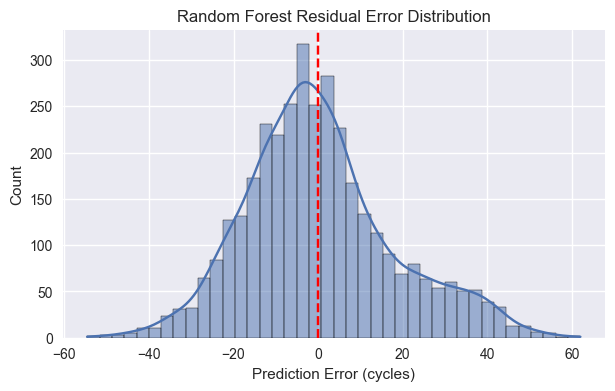

In [8]:
residuals = y_pred_rul - y_true_rul

plt.figure(figsize=(7,4))
sns.histplot(residuals, bins=40, kde=True)
plt.axvline(0, color="red", linestyle="--")
plt.xlabel("Prediction Error (cycles)")
plt.title("Random Forest Residual Error Distribution")
plt.show()

Error vs Actual RUL

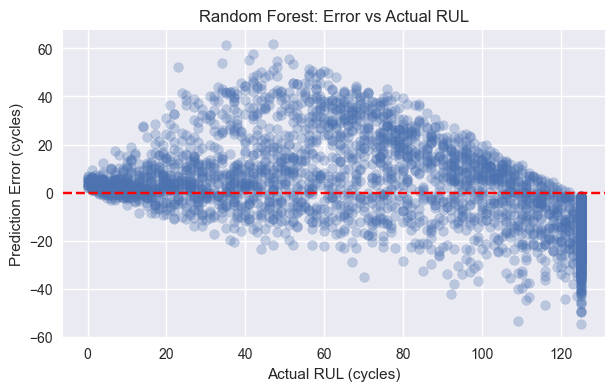

In [9]:
plt.figure(figsize=(7,4))
plt.scatter(y_true_rul, residuals, alpha=0.3)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Actual RUL (cycles)")
plt.ylabel("Prediction Error (cycles)")
plt.title("Random Forest: Error vs Actual RUL")
plt.grid(True)
plt.show()

Feature Importance

In [10]:

importances = model.feature_importances_

# Build feature names for flattened input
feature_names = []
for i in range(30):
    for f in features:
        feature_names.append(f"{f}_t-{30-i}")

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

importance_df.head(10)

,feature,importance
412,sensor11_t-1,0.471141
398,sensor11_t-2,0.106917
411,sensor9_t-1,0.047938
397,sensor9_t-2,0.029188
384,sensor11_t-3,0.024434
383,sensor9_t-3,0.021330
413,sensor12_t-1,0.017063
408,sensor4_t-1,0.012914
399,sensor12_t-2,0.009773
370,sensor11_t-4,0.007110


Top Feature Importance Plot

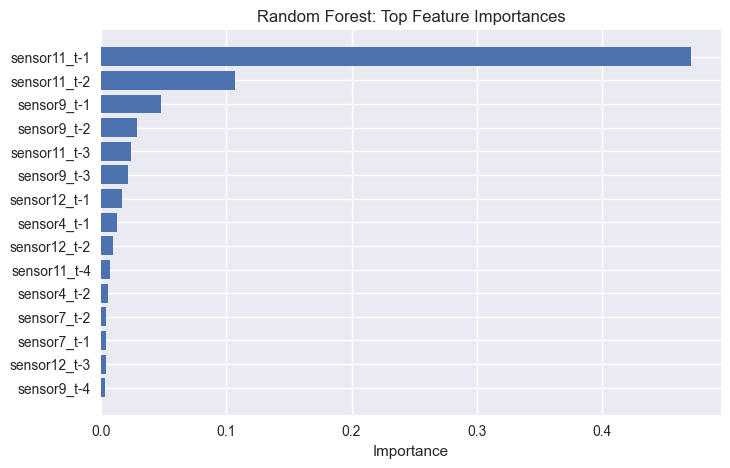

In [11]:
top_features = importance_df.head(15)

plt.figure(figsize=(8,5))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Random Forest: Top Feature Importances")
plt.show()

Sensor Degradation

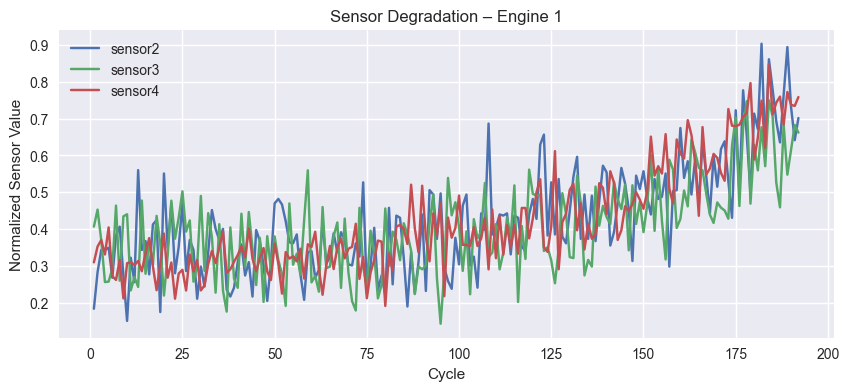

In [12]:
def plot_sensor_degradation(engine_id, df, features):
    engine_df = df[df.engine_id == engine_id]

    plt.figure(figsize=(10,4))
    for f in features[:3]:
        plt.plot(engine_df["cycle"], engine_df[f], label=f)

    plt.xlabel("Cycle")
    plt.ylabel("Normalized Sensor Value")
    plt.title(f"Sensor Degradation – Engine {engine_id}")
    plt.legend()
    plt.show()


plot_sensor_degradation(1, train_df, features)

Random Forest Metrics

In [13]:
metrics_rf = {
    "RMSE": np.sqrt(mean_squared_error(y_val, y_pred)),
    "MAE": mean_absolute_error(y_val, y_pred),
    "R2": r2_score(y_val, y_pred)
}

metrics_rf

{'RMSE': np.float64(0.14148757280180452),
 'MAE': 0.10897831933031485,
 'R2': 0.821755924722211}